# PySLAM Analysis Notebook

This notebook loads data from PySLAM trajectory files and frames to analyze results

In [ ]:
online_poses_path = "results/metrics_20250428_144655_frame_to_frame/trajectory_online.txt"
# Sample line = 0.99976625736828173 -0.0096848061004579621 -0.019329644554804667 0.053494451619213915 0.0097149148417431559 0.99995173688927541 0.0014643502787692246 -0.0071527894115715387 0.019314529697516222 -0.0016517938484523994 0.99981209260522852 0.028181244859041363
#Read and convert to poses
import numpy as np

poses = []
with open(online_poses_path, "r") as f:
    for line in f:
        if line.startswith("#"):
            continue
        numbers = list(map(float, line.strip().split()))
        assert len(numbers) == 12
        pose = np.array(numbers).reshape(3,4)
        T = np.eye(4)
        T[:3, :4]  = pose
        poses.append(T)

poses = np.array(poses)
print(poses.shape)
print(poses[0])

starting_frame = 30
ending_frame = 80

# Import required libraries
import os
import sys
import cv2
import matplotlib.pyplot as plt
import numpy as np
from config import Config
from dataset_factory import dataset_factory
from camera import PinholeCamera
from ground_truth import groundtruth_factory
from utils_geom import xyzq2Tmat
from utilities.utils_delaunay import *

# Initialize configuration
config = Config()

# Create dataset
dataset = dataset_factory(config)
print(f"Dataset: {dataset.name}")
print(f"Total frames: {dataset.num_frames}")

# Initialize camera
camera = PinholeCamera(config)
depth_factor = 1/camera.depth_factor

# Initialize ground truth if available
groundtruth = groundtruth_factory(config.dataset_settings)
if groundtruth:
    print("Ground truth available")
    gt_traj3d, gt_poses, gt_timestamps = groundtruth.getFull6dTrajectory()


def display_frame(img, title="Frame"):
    """Display a frame with matplotlib"""
    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()

# Get a sample frame
if dataset.isOk():
    frame_id = 30
    img1 = dataset.getImageColor(frame_id)
    depth1 = dataset.getDepth(frame_id)
    
    # Display the frame
    if img1 is not None:
        print(f"Frame {frame_id} loaded, shape: {img1.shape}")
        display_frame(img1, f"Frame {frame_id}")
        
        # If depth is available, visualize it
        if depth1 is not None:
            plt.figure(figsize=(12, 8))
            plt.imshow(depth1, cmap='jet')
            plt.title(f"Depth for Frame {frame_id}")
            plt.colorbar(label="Depth")
            plt.show()
    else:
        print(f"Failed to load frame {frame_id}")
else:
    print("Dataset is not properly initialized")

# Get a sample frame
if dataset.isOk():
    frame_id = 50
    img2 = dataset.getImageColor(frame_id)
    depth2 = dataset.getDepth(frame_id)
    
    # Display the frame
    if img2 is not None:
        print(f"Frame {frame_id} loaded, shape: {img2.shape}")
        display_frame(img2, f"Frame {frame_id}")
        
        # If depth is available, visualize it
        if depth2 is not None:
            plt.figure(figsize=(12, 8))
            plt.imshow(depth2, cmap='jet')
            plt.title(f"Depth for Frame {frame_id}")
            plt.colorbar(label="Depth")
            plt.show()
    else:
        print(f"Failed to load frame {frame_id}")
else:
    print("Dataset is not properly initialized")


# Extract superpoint features and match frames using lightglue.
# Create point clouds from the depth images
# Apply online trajecory poses to the point clouds - consider only frame 30 and frame 50
# Create point clouds for the matched keypoints
# Visualize the point clouds
from feature_tracker_configs import FeatureTrackerConfigs
from utils_rerun import *
from utils_depth import depth2pointcloud_with_mask
camera = PinholeCamera(config)
depth_factor = 1/camera.depth_factor #eg final value = 5000
feature_tracker_config = FeatureTrackerConfigs.LIGHTGLUE

pc1= depth2pointcloud_with_mask(depth1, img1, camera.fx, camera.fy, camera.cx, camera.cy, max_depth=50000000, mask=None, scale=depth_factor)
pc1_points, pc1_colors = pc1.points, pc1.colors

pc2= depth2pointcloud_with_mask(depth2, img2, camera.fx, camera.fy, camera.cx, camera.cy, max_depth=50000000, mask=None, scale=depth_factor)
pc2_points, pc2_colors = pc2.points, pc2.colors

import time
import rerun as rr
# Initialize rerun for visualization
if True:
    rerun_record_name = f"pyslam_{dataset.name}_{int(time.time())}"  # Add timestamp for uniqueness
    rr.init(rerun_record_name, spawn=True)
    
    rr.log("world", rr.ViewCoordinates.RIGHT_HAND_Z_UP, static=True)
    log_coordinate_axes(entity_path="world/Origin", pose=np.eye(4), scale=1)


pose1 = poses[0]
pose2 = poses[50-31]
print("pose1", pose1)
print("pose2", pose2)

log_frame_pc(frame_id=30, entity_path="world/GT/scans/", points=pc1_points, colors=pc1_colors, pose = pose1, fraction = 1.0)
log_frame_pc(frame_id=50, entity_path="world/GT/scans/", points=pc2_points, colors=pc2_colors, pose = pose2, fraction = 1.0)


print("Depth 1 max and min", np.max(depth1), np.min(depth1))
print("Depth 2 max and min", np.max(depth2), np.min(depth2))
""" 
Depth 1 max and min 15623 0
Depth 2 max and min 9019 0

Divide by 5000 to cover depth values 
"""
depth1_scaled = depth1 / 1000
depth2_scaled = depth2 / 1000
# Print max and min values of pc1 and pc2
print("Depth 1 scaled max and min", np.max(depth1_scaled), np.min(depth1_scaled))
print("Depth 2 scaled max and min", np.max(depth2_scaled), np.min(depth2_scaled))

# TODO: Create feature extractor and matcher classes - superpoint and lightglue

from thirdparty.LightGlue.lightglue import LightGlue, SuperPoint, DISK
from thirdparty.LightGlue.lightglue import viz2d
from thirdparty.LightGlue.lightglue.utils import rbd
num_features = 1000
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
extractor = SuperPoint(max_num_keypoints=num_features).eval().to(device)
matcher = LightGlue(features="superpoint").eval().to(device)

import torch

print("img1 shape", img1.shape) 
print("img2 shape", img2.shape)
print("img1 dtype", img1.dtype)
print("img2 dtype", img2.dtype)
img1_torch_HWC = torch.from_numpy(img1).permute(2, 0, 1).unsqueeze(0).float() / 255.0
img2_torch_HWC = torch.from_numpy(img2).permute(2, 0, 1).unsqueeze(0).float() / 255.0

# Convert images to torch tensors

img1_torch_HWC = img1_torch_HWC.to(device)
img2_torch_HWC = img2_torch_HWC.to(device)

ref_feat = extractor.extract(img1_torch_HWC.to(device))
curr_feat = extractor.extract(img2_torch_HWC.to(device))
matches01 = matcher({"image0": ref_feat, "image1": curr_feat})
feats0, feats1, matches01 = [
    rbd(x) for x in [ref_feat, curr_feat, matches01]
]  # remove batch dimension

kpts0, kpts1, matches = feats0["keypoints"], feats1["keypoints"], matches01["matches"]
m_kpts0, m_kpts1 = kpts0[matches[..., 0]], kpts1[matches[..., 1]]


print("Number of keypoints in ref image: ", len(kpts0))
print("Number of keypoints in curr image: ", len(kpts1))
print("shape of the image1: ", img1_torch_HWC.shape)
print("shape of the image2: ", img2_torch_HWC.shape)

print("matches shape: ", matches.shape)




print("matches01 keys: ", matches01.keys())
print("feats0 keys: ", feats0.keys())
print("kpts0 keys: ", kpts0.shape)
print("m_kpts0 keys:", m_kpts0.shape)
print("ref_img shape: ", img1.shape)

""" 
Number of keypoints in ref image:  1000
Number of keypoints in curr image:  1000
shape of the image1:  torch.Size([1, 3, 720, 1280])
shape of the image2:  torch.Size([1, 3, 720, 1280])
matches shape:  torch.Size([640, 2])
matches01 keys:  dict_keys(['matches0', 'matches1', 'matching_scores0', 'matching_scores1', 'stop', 'matches', 'scores', 'prune0', 'prune1'])
feats0 keys:  dict_keys(['keypoints', 'keypoint_scores', 'descriptors', 'image_size'])
kpts0 keys:  torch.Size([1000, 2])
m_kpts0 keys: torch.Size([640, 2])
ref_img shape:  (720, 1280, 3)
"""


def visualize_matches(img0, img1, kpts0, kpts1, matches, color=(0, 255, 0), thickness=2, radius=6,  add_text = False):
    """
    Visualizes keypoint matches between two images.

    Args:
        img0: The first image (torch 1,3,H,W) or (numpy H,W,3).
        img1: The second image (torch 1,3,H,W) or (numpy H,W,3).
        kpts0: Keypoints in the first image (torch.Tensor, Nx2).
        kpts1: Keypoints in the second image (torch.Tensor, Nx2).
        matches: A tensor of shape (M, 2) where each row contains indices (i, j) 
                 indicating that kpts0[i] matches kpts1[j].
        color:  Color of the lines and circles (B, G, R). Default: Green.
        thickness: Thickness of the connecting lines.
        radius: Radius of the keypoint circles.
        add_text : to add the text or not.

    Returns:
        output_img:  A combined image with matches visualized.
    """
    if isinstance(img0, torch.Tensor):
        img0 = img0.squeeze(0).permute(1, 2, 0).cpu().numpy()
    if isinstance(img1, torch.Tensor):
        img1 = img1.squeeze(0).permute(1, 2, 0).cpu().numpy()

    # Convert to uint8
    img0 = (img0 ).astype(np.uint8)
    img1 = (img1 ).astype(np.uint8)

    # Convert to RGB
    img0 = cv2.cvtColor(img0, cv2.COLOR_BGR2RGB)
    img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)

    # Create a blank canvas for the output image
    output_img = np.hstack((img0, img1))

    # Draw keypoints and matches
    for i in range(matches.shape[0]):
        # Every 40th match is drawn
        # if i % 3 != 0:
        #     continue
        pt0 = tuple(kpts0[matches[i, 0]].int().cpu().numpy())
        pt1 = tuple(kpts1[matches[i, 1]].int().cpu().numpy() + np.array([img0.shape[1], 0]))

        cv2.circle(output_img, pt0, radius, color, -1)
        cv2.circle(output_img, pt1, radius, color, -1)
        # cv2.line(output_img, pt0, pt1, color, thickness)

        
    return output_img
# Visualize matches
output_img = visualize_matches(img1, img2, kpts0, kpts1, matches, add_text=True)
plt.figure(figsize=(12, 8))
plt.imshow(output_img)
plt.title("Matches between Frame 30 and Frame 50")
plt.axis('off')


def unproject_kps(depth_img, kps, camera, pose, transform_to_world=False):
    """
    input: 
    depth_img: depth image with values in meters
    kps: keypoint coordinates to be unprojected
    camera: camera object - with fx, fy, cx, cy that can be accessed by camera.fx, camera.fy, etc
    pose: 4x4 pose matrix of the camera wrt the world
    transform_to_world: if True, transform the points to world coordinates using the pose
    
    output:
    points: 3D points in the camera or world coordinates depending on the transform_to_world flag
    """
    # Unproject keypoints to 3D points
    points = []
    for kp in kps:
        x, y = int(kp[0]), int(kp[1])
        depth = depth_img[y, x]  # Get the depth value at the keypoint location
        if depth == 0:
            continue  # Skip if depth is zero
        z = depth
        x3d = (x - camera.cx) * z / camera.fx
        y3d = (y - camera.cy) * z / camera.fy
        points.append([x3d, y3d, z])

    points = np.array(points)
    if transform_to_world:
        # Transform points to world coordinates using the pose
        points_homogeneous = np.hstack((points, np.ones((points.shape[0], 1))))
        points_world = pose @ points_homogeneous.T
        return points_world[:3].T

    return points
# Unproject keypoints to 3D points
kps0 = kpts0[matches[..., 0]].int().cpu().numpy()
kps1 = kpts1[matches[..., 1]].int().cpu().numpy()
print("kps0 shape", kps0.shape)
print("kps1 shape", kps1.shape)
# Unproject keypoints to 3D points
points0 = unproject_kps(depth1_scaled, kps0, camera, pose1, transform_to_world=True)
points1 = unproject_kps(depth2_scaled, kps1, camera, pose2, transform_to_world=True)
print("points0 shape", points0.shape)
print("points1 shape", points1.shape)

# Visualize the 3D points
from utils_rerun import *
log_random_pc(entity= "kps matched in frame 1", points=points0, colors=None)
log_random_pc(entity= "kps matched in frame 2", points=points1, colors=None)



(48, 4, 4)
[[ 0.99976626 -0.00968481 -0.01932964  0.05349445]
 [ 0.00971491  0.99995174  0.00146435 -0.00715279]
 [ 0.01931453 -0.00165179  0.99981209  0.02818124]
 [ 0.          0.          0.          1.        ]]


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


## Load Dataset and Configuration

Initialize the necessary components to load frames from the dataset

 dataset_factory - sensor_type: RGBD
Processing TUM Sequence
Dataset: ball
Total frames: 931
using groundtruth:  tum
[TumGroundTruth] base_path:  /home/shashank/Documents/UniBonn/Sem4/ThesisPrep/pyslam/data/TUM/ball
[associate] Number of matches: 931
Ground truth available


## Extract Frames and Visualize

Load frames from starting_frame to ending_frame and visualize them

Frame 30 loaded, shape: (720, 1280, 3)


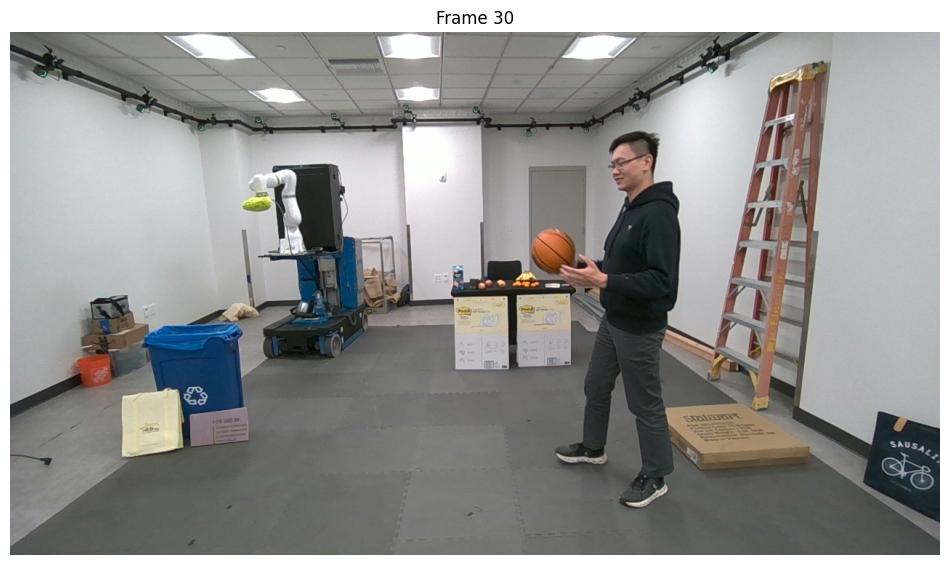

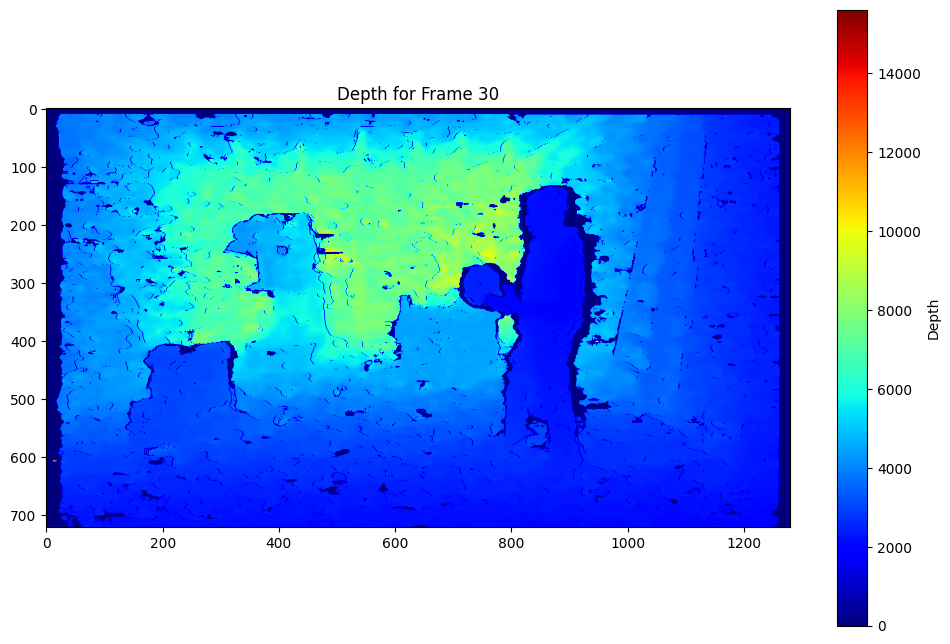

Frame 50 loaded, shape: (720, 1280, 3)


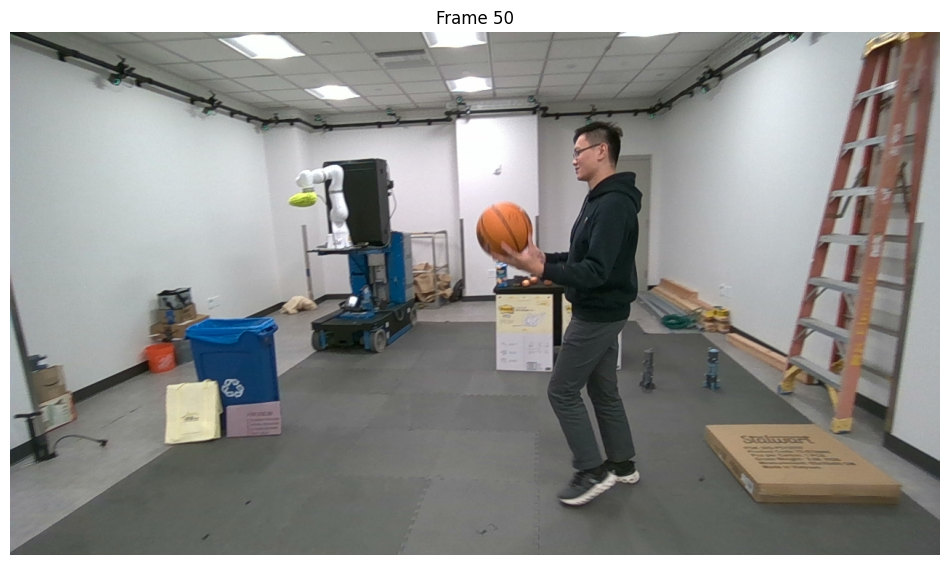

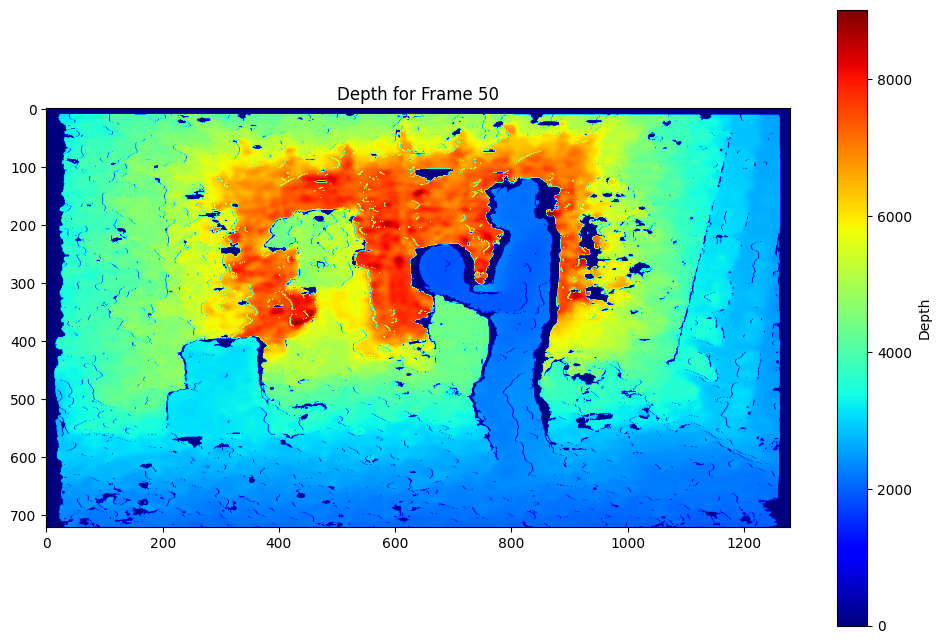

2025-04-29 15:58:03.424640: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745935083.441339  228451 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745935083.446482  228451 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1745935083.461755  228451 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1745935083.461793  228451 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1745935083.461796  228451 computation_placer.cc:177] computation placer alr

pose1 [[ 0.99976626 -0.00968481 -0.01932964  0.05349445]
 [ 0.00971491  0.99995174  0.00146435 -0.00715279]
 [ 0.01931453 -0.00165179  0.99981209  0.02818124]
 [ 0.          0.          0.          1.        ]]
pose2 [[ 0.98636883  0.01861291 -0.16349337  0.2825636 ]
 [-0.01560703  0.99968509  0.01965067 -0.03424058]
 [ 0.16380764 -0.01683117  0.9863487   0.22347675]
 [ 0.          0.          0.          1.        ]]


Depth 1 max and min 15623 0
Depth 2 max and min 9019 0
Depth 1 scaled max and min 15.623 0.0
Depth 2 scaled max and min 9.019 0.0


img1 shape (720, 1280, 3)
img2 shape (720, 1280, 3)
img1 dtype uint8
img2 dtype uint8


Number of keypoints in ref image:  1000
Number of keypoints in curr image:  1000
shape of the image1:  torch.Size([1, 3, 720, 1280])
shape of the image2:  torch.Size([1, 3, 720, 1280])
matches shape:  torch.Size([640, 2])
matches01 keys:  dict_keys(['matches0', 'matches1', 'matching_scores0', 'matching_scores1', 'stop', 'matches', 'scores', 'prune0', 'prune1'])
feats0 keys:  dict_keys(['keypoints', 'keypoint_scores', 'descriptors', 'image_size'])
kpts0 keys:  torch.Size([1000, 2])
m_kpts0 keys: torch.Size([640, 2])
ref_img shape:  (720, 1280, 3)


" \nNumber of keypoints in ref image:  1000\nNumber of keypoints in curr image:  1000\nshape of the image1:  torch.Size([1, 3, 720, 1280])\nshape of the image2:  torch.Size([1, 3, 720, 1280])\nmatches shape:  torch.Size([640, 2])\nmatches01 keys:  dict_keys(['matches0', 'matches1', 'matching_scores0', 'matching_scores1', 'stop', 'matches', 'scores', 'prune0', 'prune1'])\nfeats0 keys:  dict_keys(['keypoints', 'keypoint_scores', 'descriptors', 'image_size'])\nkpts0 keys:  torch.Size([1000, 2])\nm_kpts0 keys: torch.Size([640, 2])\nref_img shape:  (720, 1280, 3)\n"

(-0.5, 2559.5, 719.5, -0.5)

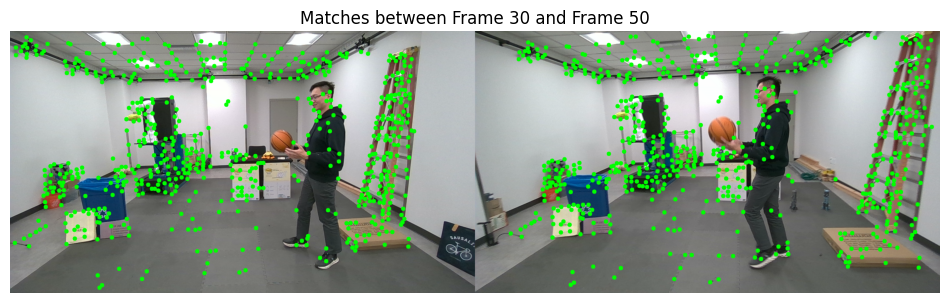

kps0 shape (640, 2)
kps1 shape (640, 2)
points0 shape (621, 3)
points1 shape (622, 3)


[2025-04-29T13:58:12Z WARN  re_log_types::path::parse_path] When parsing the entity path "kps matched in frame 1": Unescaped whitespace. The path will be interpreted as /kps\ matched\ in\ frame\ 1
[2025-04-29T13:58:12Z WARN  re_log_types::path::parse_path] When parsing the entity path "kps matched in frame 2": Unescaped whitespace. The path will be interpreted as /kps\ matched\ in\ frame\ 2


: 